In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import csv
import matplotlib.pyplot as plt
import json


from sklearn.metrics import roc_auc_score, roc_curve

import scipy.stats as stats

In [51]:
df = pd.read_csv('Data/train.csv')
data = pd.read_csv('data_clear.csv')
iv_table = pd.read_csv('iv_table.csv')
f_table = pd.read_csv('f_table.csv')
gini_score = np.load("gini_score.npy", allow_pickle=True).item()
auc_score = np.load("auc_score.npy", allow_pickle=True).item()
fpr = np.load("fpr.npy", allow_pickle=True)
tpr = np.load("tpr.npy", allow_pickle=True)
thresholds = np.load("thresholds.npy", allow_pickle=True)
top = []
with open("top.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    for row in reader:
        roww = []
        for el in row:
            roww.append(float(el))
        top.append(roww)
corrs = np.load("corrs.npy")

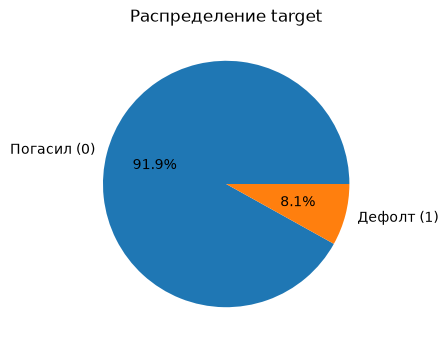

,mean,min,max,median,std,n_missing,share_missing
average_commonarea,0.044536,0.0,1.0,0.0211,0.075478,182677,0.698884
mode_commonarea,0.042447,0.0,1.0,0.0191,0.073762,182677,0.698884
median_commonarea,0.044514,0.0,1.0,0.0208,0.075545,182677,0.698884
non_living_apartments_mode,0.007983,0.0,1.0,0.0000,0.045072,181529,0.694492
non_living_apartments_avg,0.008717,0.0,1.0,0.0000,0.046519,181529,0.694492
...,...,...,...,...,...,...,...
document_16_flag,0.009802,0.0,1.0,0.0000,0.098517,0,0.000000
document_15_flag,0.001224,0.0,1.0,0.0000,0.034968,0,0.000000
document_14_flag,0.002992,0.0,1.0,0.0000,0.054615,0,0.000000
document_20_flag,0.000513,0.0,1.0,0.0000,0.022636,0,0.000000


In [5]:
# Вывод статистики

# Численные колонки
num_pr = []
for column in df.select_dtypes(include=['int', 'float']):
    num_pr.append(column)

# Статистика по колонкам
stats = df[num_pr].agg(['mean', 'min', 'max', 'median', 'std']).T
stats['n_missing'] = df[num_pr].isna().sum()
stats['share_missing'] = df[num_pr].isna().mean()
stats = stats.sort_values('share_missing', ascending=False)

# Строим график распределения 0 и 1 таргете
plt.figure(figsize=(6,4))
df['target'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Погасил (0)', 'Дефолт (1)'])
plt.title('Распределение target')
pd.set_option('display.width', 1000)
plt.show()

stats

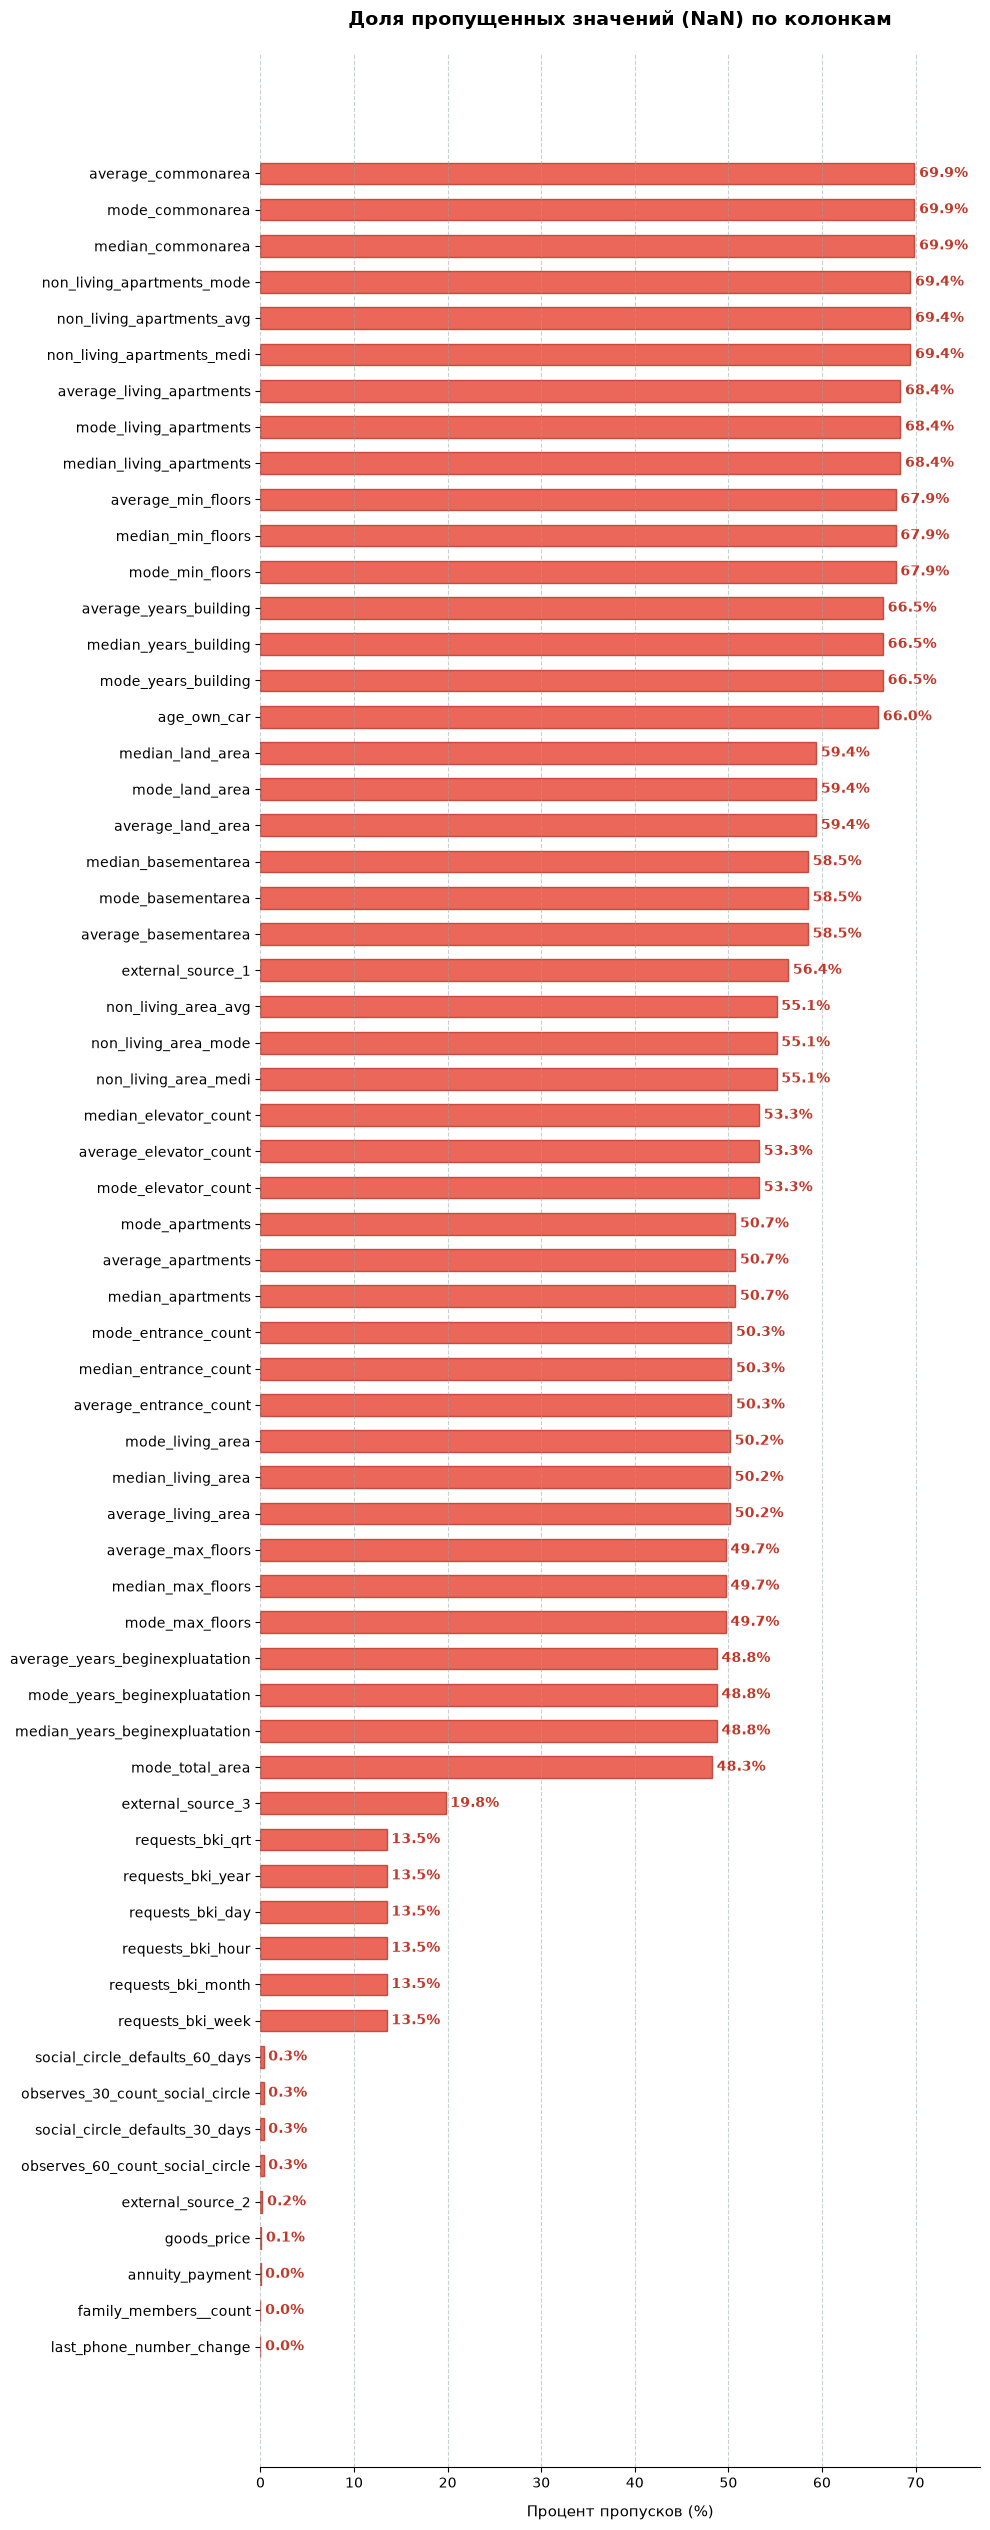

In [6]:
# Фильтруем только те колонки из вашей таблицы stats, где есть пропуски
missing_data = stats[stats['share_missing'] > 0]

if missing_data.empty:
    print("Везет! В числовых колонках вообще нет пропущенных значений (NaN).")
else:
    # Настраиваем высоту динамически в зависимости от количества колонок с NaN
    fig_height = max(4, len(missing_data) * 0.4 + 1)
    fig, ax = plt.subplots(figsize=(10, fig_height), facecolor='white')
    
    # Строим горизонтальные бары с мягким красным цветом
    bars = ax.barh(missing_data.index, missing_data['share_missing'] * 100, 
                  color='#e74c3c', alpha=0.85, edgecolor='#c0392b', height=0.6)
    
    # Добавляем текстовые метки с процентами на конец каждого бара
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.5,                  # Смещение текста чуть правее столбца
            bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%',              # Формат процента
            va='center', ha='left', 
            fontsize=10, weight='bold', color='#c0392b'
        )
                 
    # Оформление графика
    ax.set_title('Доля пропущенных значений (NaN) по колонкам', fontsize=14, pad=20, weight='bold')
    ax.set_xlabel('Процент пропусков (%)', fontsize=11, labelpad=10)
    ax.set_xlim(0, max(missing_data['share_missing'] * 100) + 7) # Запас справа под текст
    
    # Переворачиваем ось, чтобы самые пустые колонки были наверху
    ax.invert_yaxis() 
    
    # Тонкая пунктирная сетка только по вертикальной оси
    ax.grid(axis='x', linestyle='--', alpha=0.5, color='#95a5a6')
    
    # Убираем лишние границы графика для чистоты
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
        
    plt.tight_layout()
    plt.show()

In [7]:
#Аномалии
cnt = 0
anomaly_column = [] #массив со значениями: колонка - процент
for column in (data.select_dtypes(include=['float64', 'int64'])).columns:
    data_column = data[column]
    q1 = data_column.quantile(0.25)
    q3 = data_column.quantile(0.75)
    iqr = q3 - q1
    cnt_anomaly = (data_column < q1 - 1.5 * iqr).sum() + (data_column > q3 + 1.5 * iqr).sum()
    procent_of_anomaly = cnt_anomaly / data.shape[0]
    anomaly_column.append([column, procent_of_anomaly])
    cnt += 1
    # print(column, procent_of_anomaly)
anomaly_column.sort(key=lambda x: x[1], reverse=True)
anomaly_column = [row[0] for row in anomaly_column][:10]
# print(pop)
# print(cnt)

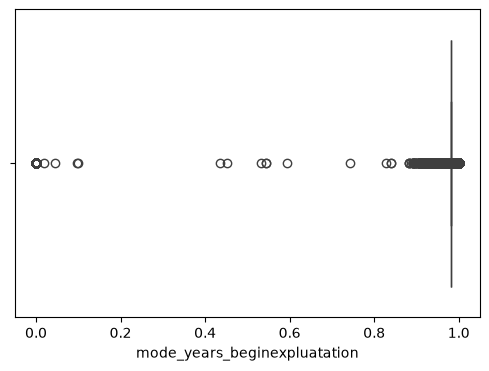

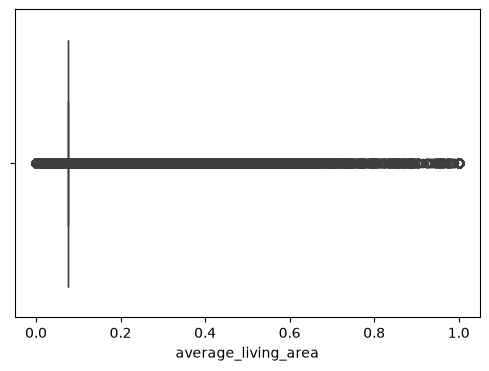

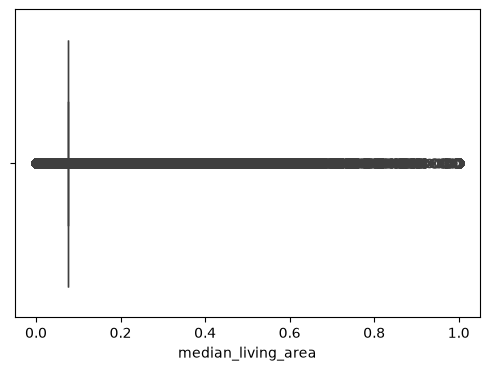

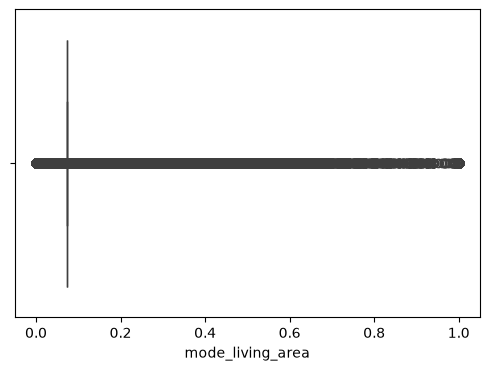

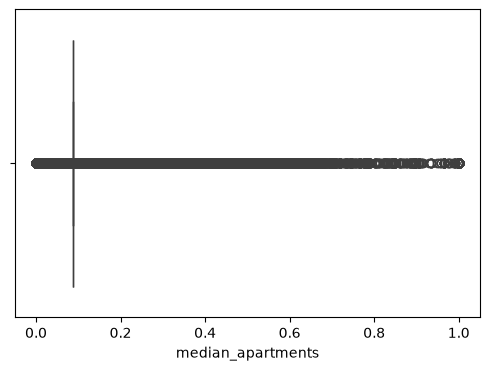

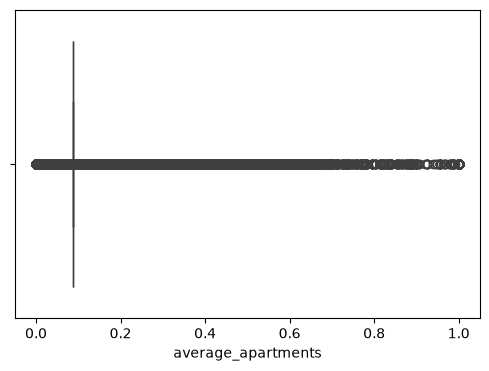

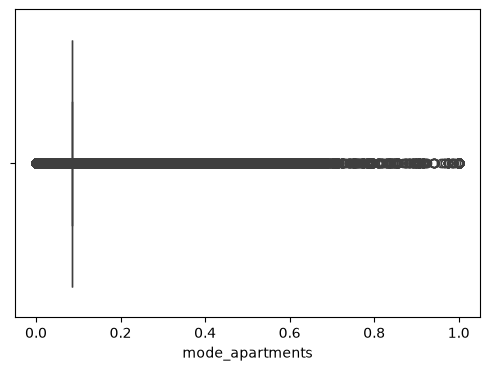

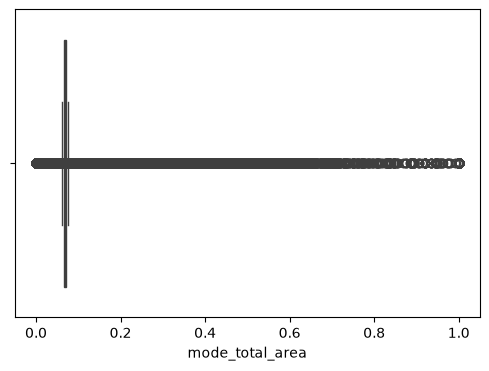

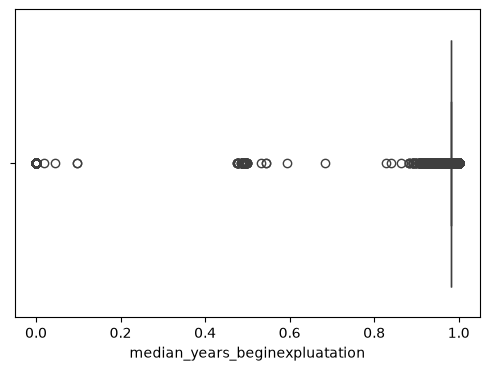

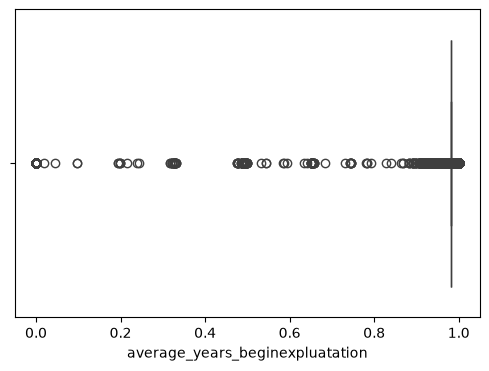

In [8]:
for column in anomaly_column:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[column])
    plt.show()

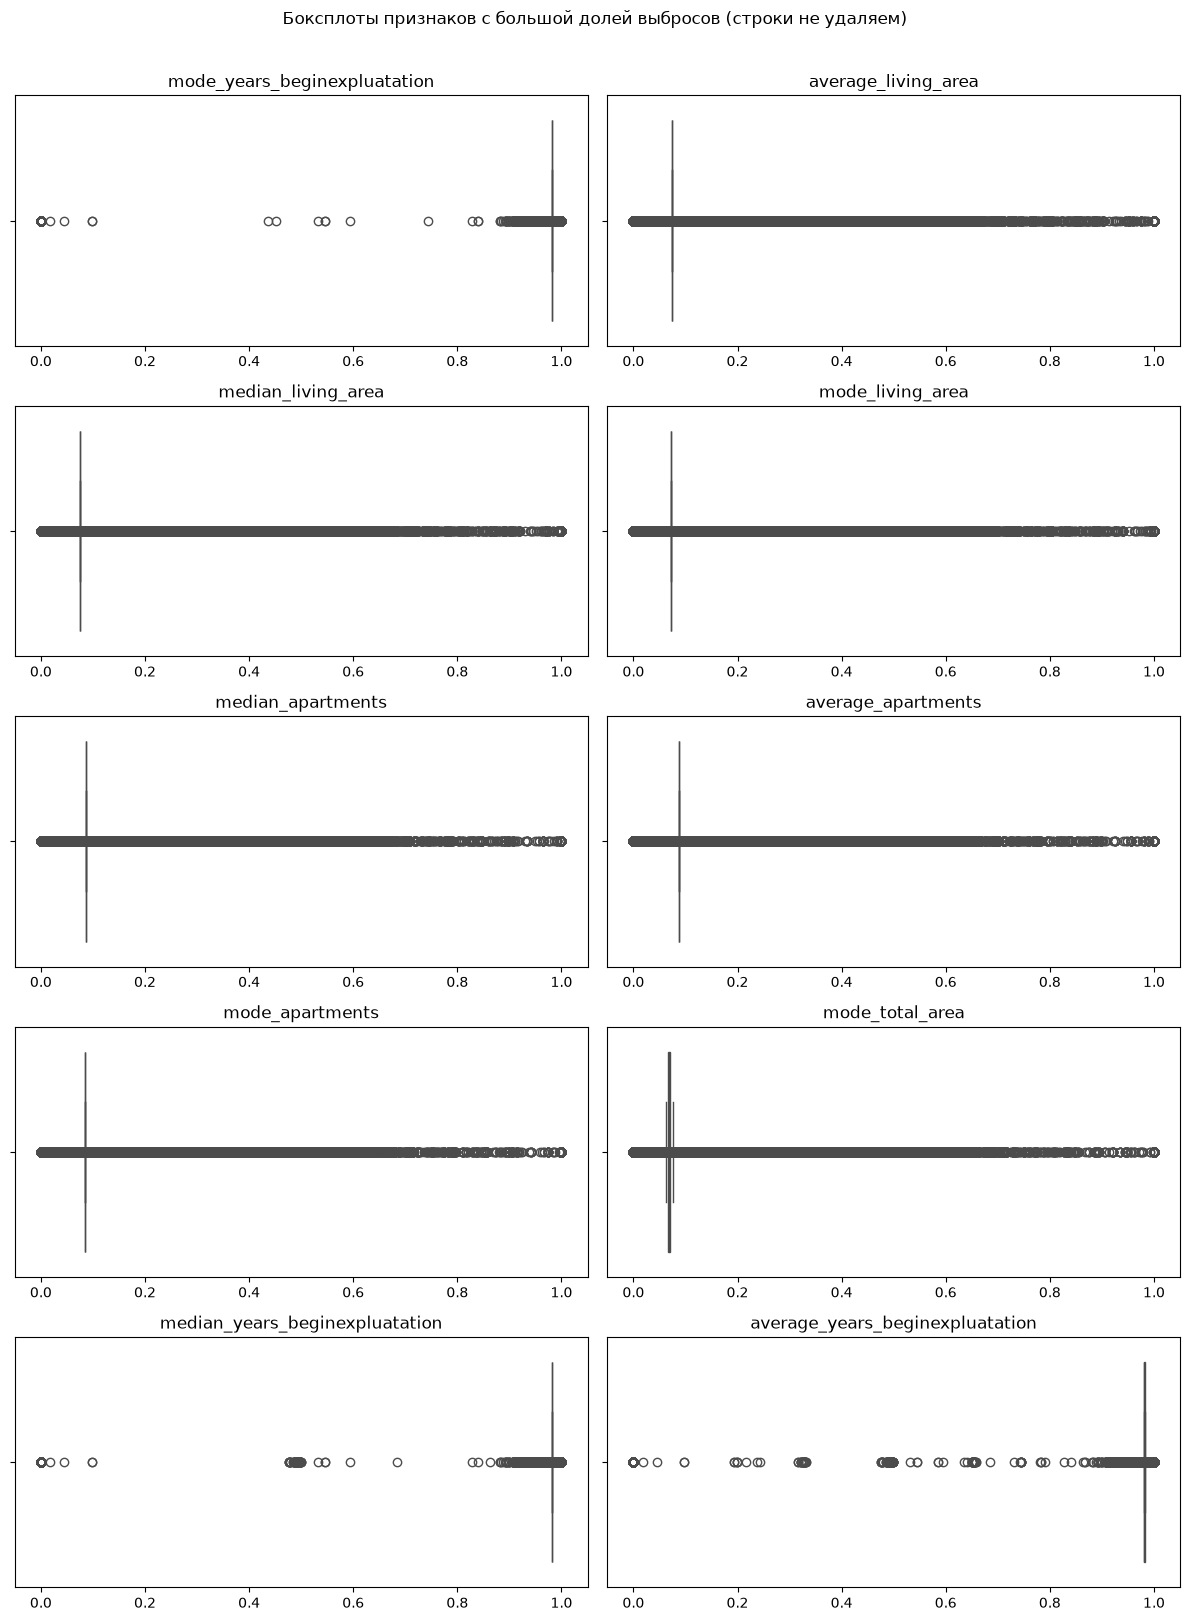

In [9]:
plot_cols = anomaly_column
n = len(plot_cols)
if n == 0:
    print('Нет признаков с большой долей выбросов — графики не нужны.')
else:
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, plot_cols):
        sns.boxplot(x=data[col], ax=ax, color='#4c72b0')
        ax.set_title(col)
        ax.set_xlabel('')
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Боксплоты признаков с большой долей выбросов (строки не удаляем)', y=1.01)
    plt.tight_layout()
    plt.show()

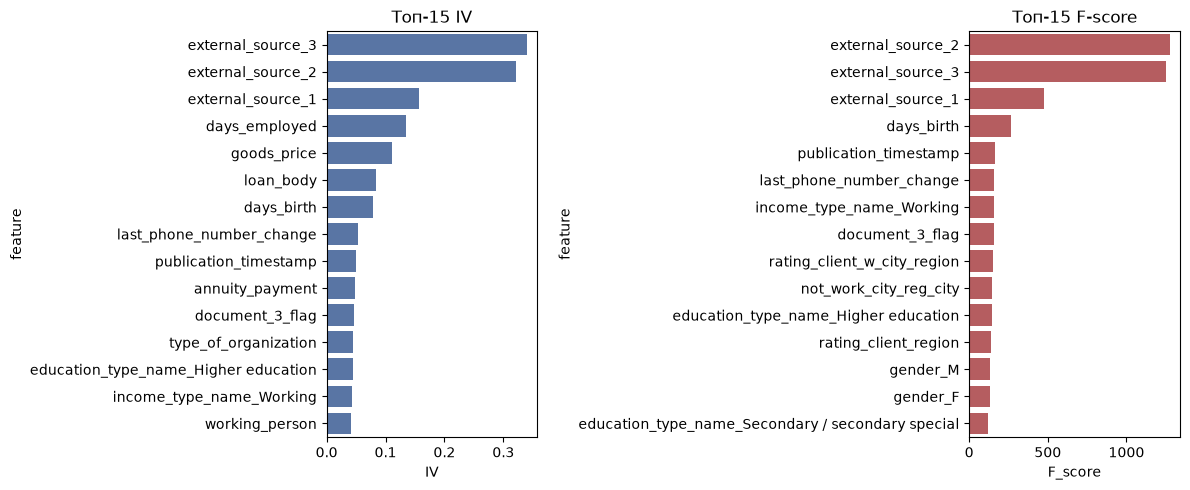

In [5]:
univariate = iv_table.merge(f_table, on='feature')
univariate['rank_IV'] = univariate['IV'].rank(ascending=False, method='min')
univariate['rank_F'] = univariate['F_score'].rank(ascending=False, method='min')
univariate = univariate.sort_values(['rank_IV', 'rank_F'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=iv_table.head(15), y='feature', x='IV', ax=axes[0], color='#4c72b0')
axes[0].set_title('Топ-15 IV')
sns.barplot(data=f_table.head(15), y='feature', x='F_score', ax=axes[1], color='#c44e52')
axes[1].set_title('Топ-15 F-score')
plt.tight_layout()
plt.show()

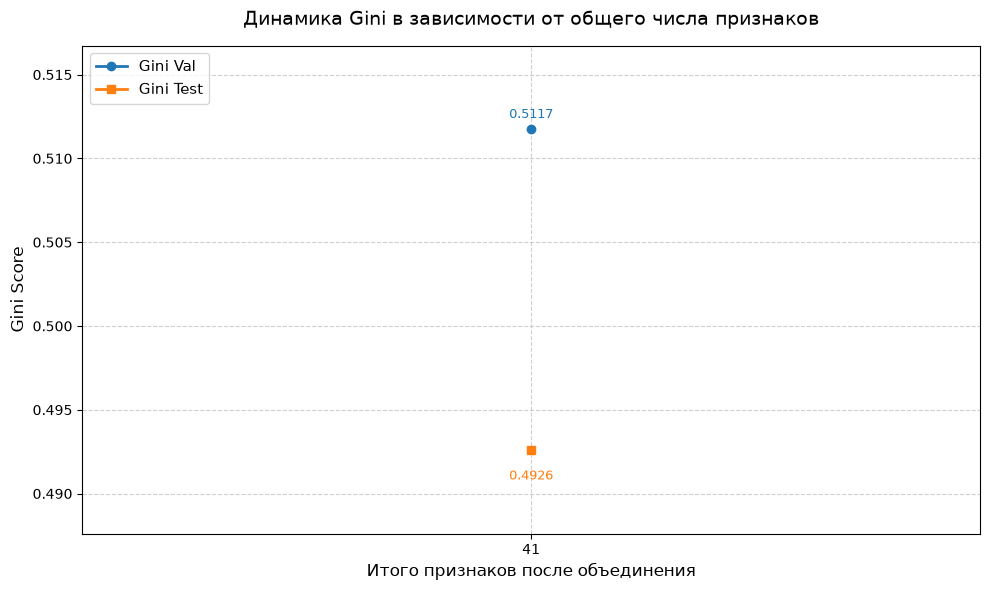

In [15]:
# Извлечение колонок
take_each = [x[0] for x in top]      # Сколько взяли из каждого списка
total_features = [x[1] for x in top]  # Сколько получилось при объединении
gini_val = [x[2] for x in top]        # Gini на val
gini_test = [x[3] for x in top]       # Gini на test

# Настройка размера графика
plt.figure(figsize=(10, 6))

# Построение линий с маркерами
plt.plot(total_features, gini_val, marker='o', color='#1f77b4', linewidth=2, label='Gini Val')
plt.plot(total_features, gini_test, marker='s', color='#ff7f0e', linewidth=2, label='Gini Test')

# Добавление подписей значений над точками (аннотации)
for x, y_val1, y_test1 in zip(total_features, gini_val, gini_test):
    plt.text(x, y_val1 + 0.0005, f"{y_val1:.4f}", ha='center', va='bottom', fontsize=9, color='#1f77b4')
    plt.text(x, y_test1 - 0.0012, f"{y_test1:.4f}", ha='center', va='top', fontsize=9, color='#ff7f0e')

# Настройка осей и сетки
plt.title('Динамика Gini в зависимости от общего числа признаков', fontsize=14, pad=15)
plt.xlabel('Итого признаков после объединения', fontsize=12)
plt.ylabel('Gini Score', fontsize=12)
plt.xticks(total_features)  # Отображать только реальные шаги на оси X
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# Ограничение по оси Y для лучшей читаемости (с запасом под аннотации)
plt.ylim(min(gini_test) - 0.005, max(gini_val) + 0.005)

# Отображение графика
plt.tight_layout()
plt.show()

In [28]:
corrs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(41, 41))

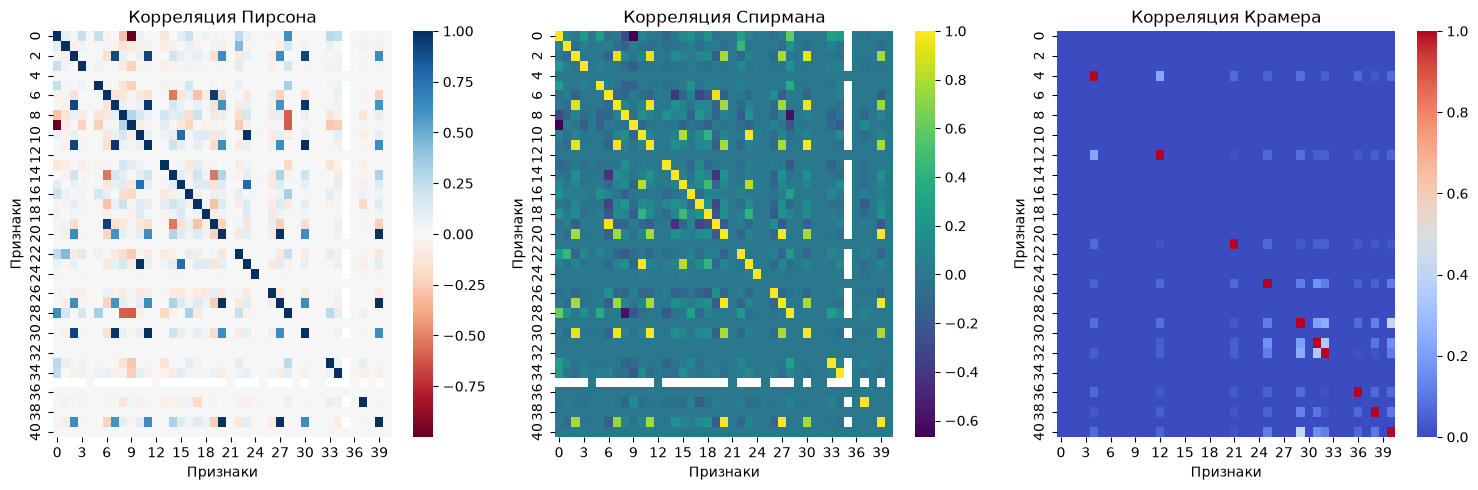

array([[ 1.        ,  0.09362673,  0.01671488, ...,  0.        ,
         0.01659589,  0.        ],
       [ 0.09362673,  1.        , -0.0507756 , ...,  0.        ,
        -0.06996725,  0.        ],
       [ 0.01671488, -0.0507756 ,  1.        , ...,  0.        ,
         0.6324106 ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.01659589, -0.06996725,  0.6324106 , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(41, 41))

In [31]:
corrs_for_sns = np.array(corrs)
corr_names = ['Корреляция Пирсона', 'Корреляция Спирмана', 'Корреляция Крамера']
cmaps = ['RdBu', 'viridis', 'coolwarm']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    sns.heatmap(corrs_for_sns[:, :, i], 
                ax=ax, 
                cmap=cmaps[i],
                cbar=True, 
                annot=False, 
                fmt='.2f')
    ax.set_title(corr_names[i])
    ax.set_xlabel('Признаки')
    ax.set_ylabel('Признаки')

plt.tight_layout()
plt.show()
corrs_for_sns[:,:,0]

(-0.01, 1.01)

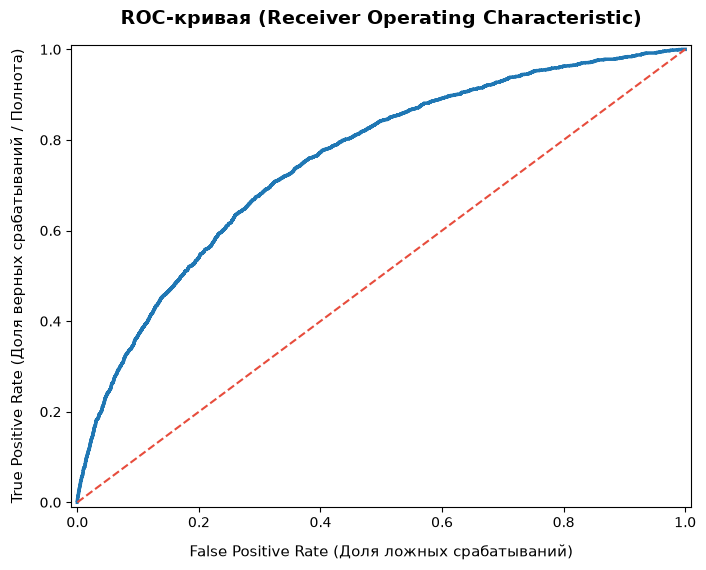

In [52]:
# 3. Строим график
plt.figure(figsize=(8, 6), facecolor='white')

# Линия нашей модели
plt.plot(fpr, tpr, color='#1f77b4', linewidth=2.5, 
         label=f'Модель CatBoost (AUC = {auc_score:.4f}, Gini = {gini_score:.4f})')

# Диагональная линия случайного угадывания (Baseline)
plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', linewidth=1.5, label='Случайная модель (AUC = 0.5000)')

# Настройка осей и оформления
plt.title('ROC-кривая (Receiver Operating Characteristic)', fontsize=14, pad=15, weight='bold')
plt.xlabel('False Positive Rate (Доля ложных срабатываний)', fontsize=11, labelpad=10)
plt.ylabel('True Positive Rate (Доля верных срабатываний / Полнота)', fontsize=11, labelpad=10)

# Ограничиваем оси от 0 до 1 с небольшим запасом для красоты
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])